In [ ]:
# Настройка Jupyter
%matplotlib inline


In [ ]:
import os

# Сохранение путей к файлам датасета
DATA_PATH = r"D:\Projects\Jupyter_Notebook_Projects\Project_2268\ieee-fraud-detection"

trans_file = os.path.join(DATA_PATH, 'train_transaction.csv')
id_file = os.path.join(DATA_PATH, 'train_identity.csv')

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
transactions = pd.read_csv(trans_file)
identity = pd.read_csv(id_file)

# Merge datasets
data = transactions.merge(identity, on="TransactionID", how="left")

# Remove columns with too many missing values
missing_ratio = data.isnull().mean()
data = data.loc[:, missing_ratio < 0.8]

# Remove constant columns
constant_cols = data.columns[data.nunique(dropna=False) <= 1]
data = data.drop(columns=constant_cols)

# Separate target and features
y = data["isFraud"]
X = data.drop(["isFraud", "TransactionID"], axis=1)

# Identify column types
num_cols = X.select_dtypes(exclude=["object"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Fill missing values
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Unknown")

# Encode categorical variables
le = LabelEncoder()

for c in cat_cols:
    X[c] = le.fit_transform(X[c].astype(str))


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Сохранение ОЧИЩЕННЫХ данных
np.savez('artifacts/preprocessed_data.npz',
         X_train=X_train.astype(np.float32),
         y_train=y_train.astype(np.int64),
         X_test=X_test.astype(np.float32),
         y_test=y_test.astype(np.int64))
print("Данные сохранены")

Данные сохранены


In [ ]:
# Обучение Random Forest
print("\nОбучение Random Forest")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, f1_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Загрузка предобработанных данных (если перезапустили kernel)
data = np.load('artifacts/preprocessed_data.npz')
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']
print(f"Данные загружены: train={X_train.shape}, test={X_test.shape}")


Обучение Random Forest
Данные загружены: train=(472432, 358), test=(118108, 358)


In [ ]:
# Настройка архитектуры модели
rf_base = RandomForestClassifier(
    n_estimators=100,        # 100 деревьев
    max_depth=12,            # ограничение глубины (против переобучения)
    min_samples_split=100,   # минимум для разбиения
    min_samples_leaf=50,     # минимум в листе
    max_features='sqrt',     # sqrt(N_features) ~20 из 430
    class_weight='balanced', # автоматический вес для дисбаланса
    n_jobs=-1,               # все ядра CPU
    random_state=42
)

print("Обучение базовой модели...")
start_time = time.time()
rf_base.fit(X_train, y_train)
train_time = (time.time() - start_time) / 60
print(f"Обучение завершено за {train_time:.1f} мин")

Обучение базовой модели...
Обучение завершено за 0.8 мин


RF ROC-AUC: 0.8949087128052571
RF F1-score: 0.3055857637172516
RF PR-AUC: 0.5400902696761465


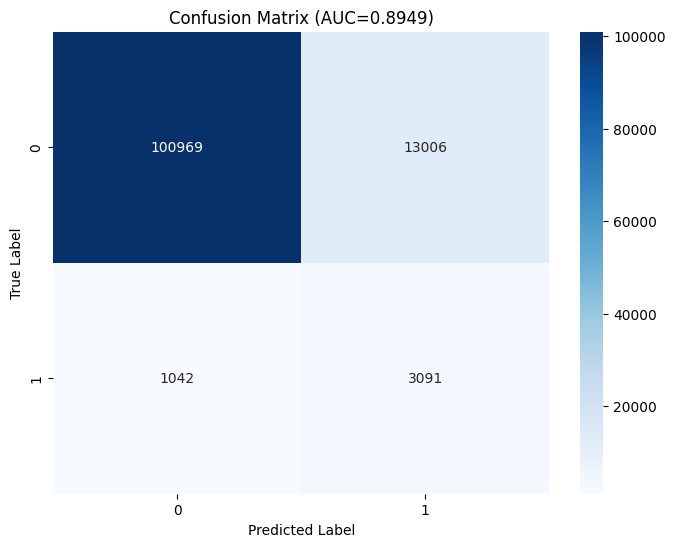

In [ ]:
# Оценка модели
y_pred = rf_base.predict(X_test)
y_proba = rf_base.predict_proba(X_test)[:, 1]

# Ключевые метрики для fraud detection
roc_auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
pr = average_precision_score(y_test, y_proba)


print("RF ROC-AUC:", roc_auc)
print("RF F1-score:", f1)
print("RF PR-AUC:", pr)

# Confusion Matrix
cm_base = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (AUC={roc_auc:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('artifacts/rf_base_cm.png', dpi=300, bbox_inches='tight')
plt.show()